In [2]:
import geopandas as gpd
import numpy as np
import osmnx as ox
import matplotlib as plt

In [3]:
# Download city boundaries
place = "Tampa, Florida, USA"
boundary = ox.geocode_to_gdf(place)

In [4]:
# Download the road map data
graph = ox.graph_from_place(place, network_type="drive")

# Project the graph to local UTM -> avoiding distortion
graph_proj = ox.project_graph(graph)

In [5]:
# Generating 300 random (x,y) points and stroring in list points[]
min_x, min_y, max_x, max_y = boundary.total_bounds

points = []
for _ in range(300):
    x = np.random.uniform(min_x, max_x)
    y = np.random.uniform(min_y, max_y)
    points.append((x,y))


<Axes: >

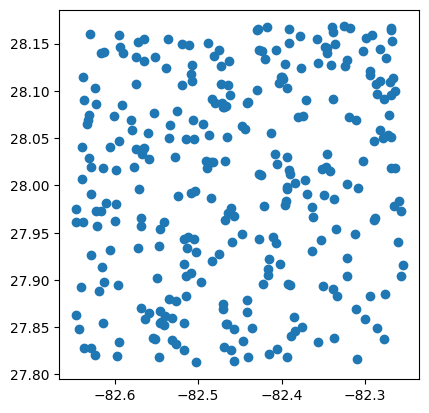

In [6]:
# Creating a GDF 
delivery_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(
        [p[0] for p in points],
        [p[1] for p in points]
        ),
        # Lat and Long coordinate system
        crs="EPSG:4326"
    )
delivery_gdf.plot()

In [9]:
delivery_gdf_proj = delivery_gdf.to_crs(graph_proj.graph['crs'])
nodes = ox.distance.nearest_nodes(
    graph_proj, delivery_gdf_proj.geometry.x,
    delivery_gdf_proj.geometry.y)

nodes

array([   97936395, 13625809254,    97834215,   260300015,    97781784,
          97813065,    97802396,    97787153,    97876948,  2139382592,
          97800401,    97787153,    97787153,    98002953,    97796399,
         931486567,    97870333,    97936798,  2139382640,    97953588,
         600668665,    97812970,  2139382640,  5920487841,    97744026,
          97836291,    97775055, 13625809254,    97885270,  5865929774,
          97810675,    97758703,   360708009, 13716245849,   360708009,
          97784487,    97863897,   667933698,   360708009,    97936395,
          97741060,    97825541,   360708009,   360708009,   360708009,
       11256466866,    97787153,   360708009,    97869501,    97791218,
         360708009,    97768402,    97787153,    97813065,  2140060200,
       13625809254,   360708009,    97773214,    97877651,    97876619,
         360708009,   360708009,    97999390,  7079393085, 13544657407,
          97787153,  2139382640,    97999390,    97789315,    97

In [ ]:
delivery_gdf = delivery_gdf[
    delivery_gdf.within(boundary.geometry.iloc[0])]

<Axes: >

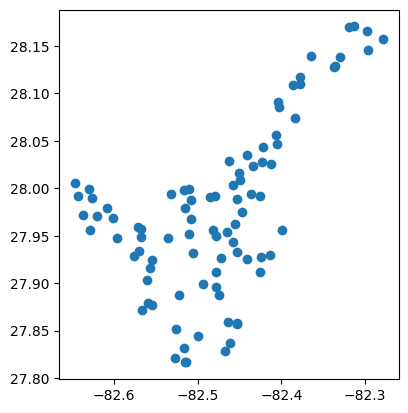

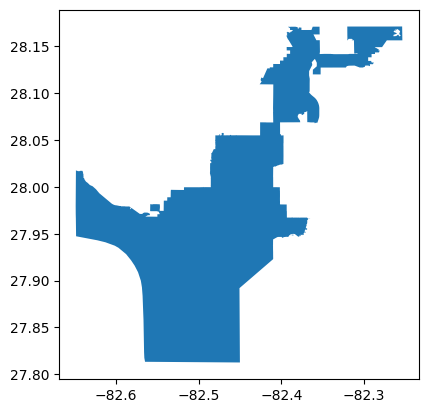

In [17]:
delivery_gdf.plot()
boundary.plot()